# Monte Carlo Simulations

In this notebook, I run Monte Carlo simulations and view the results of varying alpha/beta/gamma.

In [43]:
# Libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm
import matplotlib.ticker as mticker

In [2]:
os.getcwd()

"/Users/jananidhileepan/Desktop/Don't. Even./University/Imperial College London/Year 2/Dissertation/GitHub/fairness_smoke_alarm/src"

In [3]:
from changepoint_detection_functions import (
    CUSUMDetector,
    referee_cusum,
    EWMAResidualDetector,
    referee_ewma,
    and_or_gate,
    and_or_gate_referee,
    miss_rate
)

from fairness_metrics import unfairness_score

## 1. Convert boostrapped standard errors to a 3x3 matrix

In [4]:
boot_df = pd.read_csv("../data/processed/bootstrap.csv", index_col = 0)

Sigma = np.cov(boot_df[["DP", "EO", "CAL"]].values, rowvar=False)

In [5]:
def sigma_hat(w, Sigma):
    return np.sqrt(w @ Sigma @ w)

w = np.array([1/3, 1/3, 1/3])
sigma_hat(w, Sigma)

0.0004917382180160006

## 2. Load the fairness data and build the four referees

In [6]:
df_fairness = pd.read_csv("../data/processed/fairness_numbers.csv", index_col=0)

referee_cusum_alarm, detectors_cusum = referee_cusum(df_fairness, boot_df)
referee_ewma_alarm,  detectors_ewma  = referee_ewma(df_fairness, boot_df)

referee_and = and_or_gate_referee(detectors_cusum, detectors_ewma, gate="and")
referee_or  = and_or_gate_referee(detectors_cusum, detectors_ewma, gate="or")

## 3. Create function to evaluate all fairness metrics for a given weighting

In [7]:
def evaluate_weighting(alpha, beta, gamma, df_fairness, Sigma,
                       referee_cusum_alarm, referee_ewma_alarm,
                       referee_and, referee_or,
                       k=0.5, h=4.77, baseline_year=2007):

    composite = unfairness_score(df_fairness, alpha, beta, gamma) # weights passed
    w = np.array([alpha, beta, gamma]) # order: DP, EO, CAL
    se = sigma_hat(w, Sigma)

    cus = CUSUMDetector(composite, sigma_hat=se, k=k, h=h, baseline_year=baseline_year)
    cus.run()

    ewm = EWMAResidualDetector(composite, sigma_hat=se, baseline_year=baseline_year)
    ewm.run()

    and_alarm = and_or_gate(cus, ewm, gate="and")
    or_alarm  = and_or_gate(cus, ewm, gate="or")

    weights = {"alpha": alpha, "beta": beta, "gamma": gamma, "sigma_hat": se}

    return [
        miss_rate(cus.alarm,  referee_cusum_alarm, variant="cusum", **weights),
        miss_rate(ewm.alarm,  referee_ewma_alarm,  variant="ewma",  **weights),
        miss_rate(and_alarm,  referee_and,         variant="and",   **weights),
        miss_rate(or_alarm,   referee_or,          variant="or",    **weights),
    ]

In [8]:
def show(rows):
    return (pd.DataFrame(rows)
              [["variant", "miss_rate", "first_alarm_year",
                "n_transitions", "referee_flagged_years"]]
              .round(3))

In [9]:
composite_evaluation = evaluate_weighting(alpha = 1/3, beta = 1/3, gamma = 1/3, df_fairness = df_fairness, Sigma = Sigma,
                   referee_cusum_alarm = referee_cusum_alarm, referee_ewma_alarm = referee_ewma_alarm,
                   referee_and = referee_and, referee_or = referee_or)

show(composite_evaluation)

,variant,miss_rate,first_alarm_year,n_transitions,referee_flagged_years
0,cusum,0.222,2011,1,9
1,ewma,0.286,2010,3,7
2,and,0.429,2011,3,7
3,or,0.111,2010,1,9


## 4. Monte Carlo

In [10]:
rng = np.random.default_rng(0)
weights = rng.dirichlet([1, 1, 1], size=2000) # 2000 draws
weights.shape # (2000, 3)

weights.sum(axis=1).min(), weights.sum(axis=1).max() # At 1, as expected

(0.9999999999999998, 1.0000000000000002)

In [11]:
# Display results over the whole MC analysis

results = []
for alpha, beta, gamma in weights:
    results.extend(evaluate_weighting(
        alpha, beta, gamma,
        df_fairness, Sigma,
        referee_cusum_alarm, referee_ewma_alarm,
        referee_and, referee_or,
    ))

df_mc = pd.DataFrame(results)

summary = df_mc.groupby("variant")["miss_rate"].agg(
    mean="mean",
    sd="std",
    n="count",
)
summary["se"] = summary["sd"] / np.sqrt(summary["n"])
summary.round(4)

,mean,sd,n,se
variant,,,,
and,0.4954,0.4004,2000,0.0090
cusum,0.4237,0.4284,2000,0.0096
ewma,0.3266,0.2418,2000,0.0054
or,0.2923,0.3004,2000,0.0067


#### Analyse results

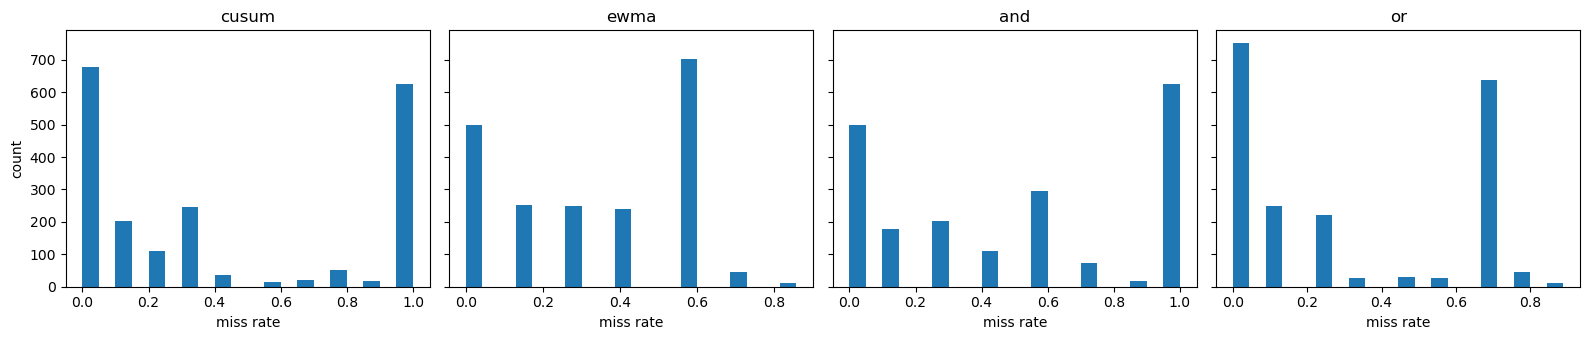

In [12]:
# Display miss rate by alarm

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

for ax, variant in zip(axes, ["cusum", "ewma", "and", "or"]):
    sub = df_mc[df_mc["variant"] == variant]["miss_rate"]
    ax.hist(sub, bins=20)
    ax.set_title(variant)
    ax.set_xlabel("miss rate")

axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()

In [13]:
# Display table of miss rates by the extremes (perfect vs total failure alarms)

df_mc.groupby("variant")["miss_rate"].agg(
    frac_perfect=lambda s: (s == 0).mean(),
    frac_total_failure=lambda s: (s == 1).mean(),
    worst=lambda s: s.max(),
).round(3)

,frac_perfect,frac_total_failure,worst
variant,,,
and,0.250,0.312,1.000
cusum,0.338,0.312,1.000
ewma,0.250,0.000,0.857
or,0.376,0.000,0.889


In [24]:
# Analyse the cliff for CUSUM and AND

def cliff_curve(df_mc, variant, n_bins=25):
    sub = df_mc[df_mc["variant"] == variant]
    binned = pd.cut(sub["gamma"], bins=n_bins)
    return sub.groupby(binned).agg(
        gamma_mid=("gamma", "mean"),
        mean_miss=("miss_rate", "mean"),
        n=("miss_rate", "size"),
    ).dropna()

curve = cliff_curve(df_mc, "cusum")
# cliff = interpolate gamma where mean_miss crosses 0.5
g, m = curve["gamma_mid"].values, curve["mean_miss"].values
i = np.where(np.diff(np.sign(m - 0.5)))[0][0]
gamma_star = np.interp(0.5, [m[i+1], m[i]], [g[i+1], g[i]])

# Print the transition zone
lo = np.interp(0.1, m[::-1], g[::-1])
hi = np.interp(0.9, m[::-1], g[::-1])
print(f"cliff at gamma = {gamma_star:.3f}  (transition {hi:.3f}–{lo:.3f})")

cliff at gamma = 0.225  (transition 0.168–0.396)


/var/folders/jk/86ps_fvj28106lt4y2bq856m0000gn/T/ipykernel_50914/1981660619.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return sub.groupby(binned).agg(


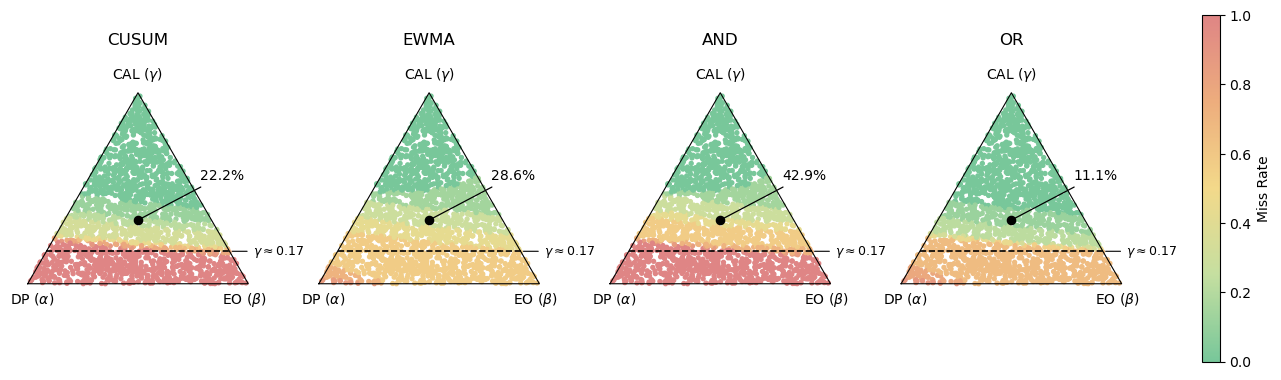

In [60]:
# View the simplex

# Pastel green to yellow to red
pastel_risk_cmap = LinearSegmentedColormap.from_list(
    "pastel_risk",
    [
        "#78C79A",  # softer green
        "#C5DFA0",  # soft yellow-green
        "#F3D98A",  # soft yellow
        "#EDAD7D",  # soft orange
        "#DF8585"   # soft red
    ]
)

def to_xy(a, b, g):
    return b + g/2, g * np.sqrt(3)/2


fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, variant in zip(axes, ["cusum", "ewma", "and", "or"]):

    sub = df_mc[df_mc["variant"] == variant]

    x, y = to_xy(
        sub["alpha"],
        sub["beta"],
        sub["gamma"]
    )

    pts = ax.scatter(
        x,
        y,
        c=sub["miss_rate"],
        cmap=pastel_risk_cmap,
        s=8,
        vmin=0,
        vmax=1
    )

    # Cliff line at gamma = 0.17 (horizontal, parallel to the DP-EO base)
    g_cliff = 0.17
    y_cliff = g_cliff * np.sqrt(3) / 2
    ax.plot([g_cliff / 2, 1 - g_cliff / 2], [y_cliff, y_cliff],
        color="k", lw=1.2, ls="--", zorder=6)
    ax.annotate(r"$\gamma \approx 0.17$",
                xy=(1 - g_cliff / 2, y_cliff),
                xytext=(1.02, y_cliff),
                ha="left", va="center", fontsize=9,
                arrowprops=dict(arrowstyle="-", color="k", lw=0.8),
                annotation_clip=False)

    # Equal-weight point: alpha = beta = gamma = 1/3
    eq_alpha = eq_beta = eq_gamma = 1/3

    eq_x, eq_y = to_xy(
        eq_alpha,
        eq_beta,
        eq_gamma
    )

    # Find the simulated point closest to equal weighting
    eq_row = sub.loc[
        (
            (sub["alpha"] - eq_alpha)**2
            + (sub["beta"] - eq_beta)**2
            + (sub["gamma"] - eq_gamma)**2
        ).idxmin()
    ]

    eq_miss_rate = eq_row["miss_rate"]

    # Black dot at equal weighting
    ax.scatter(
        eq_x,
        eq_y,
        color="black",
        s=35,
        zorder=5
    )

    # Line from dot to percentage
    ax.annotate(
        f"{eq_miss_rate:.1%}",
        xy=(eq_x, eq_y),
        xytext=(eq_x + 0.28, eq_y + 0.20),
        ha="left",
        va="center",
        fontsize=10,
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.9
        ),
        annotation_clip=False
    )

    # Simplex outline
    ax.plot(
        [0, 1, 0.5, 0],
        [0, 0, np.sqrt(3)/2, 0],
        color="k",
        lw=0.8
    )

    ax.set_title(variant.upper(), pad=28)
    ax.set_aspect("equal")
    ax.axis("off")

    ax.text(0.02, -0.03, r"DP ($\alpha$)",
            ha="center", va="top", fontsize=10)
    ax.text(0.98, -0.03, r"EO ($\beta$)",
            ha="center", va="top", fontsize=10)
    ax.text(
        0.5,
        np.sqrt(3)/2 + 0.04,
        r"CAL ($\gamma$)",
        ha="center",
        va="bottom",
        fontsize=10
    )

fig.colorbar(
    pts,
    ax=axes,
    label="Miss Rate"
)

plt.show()

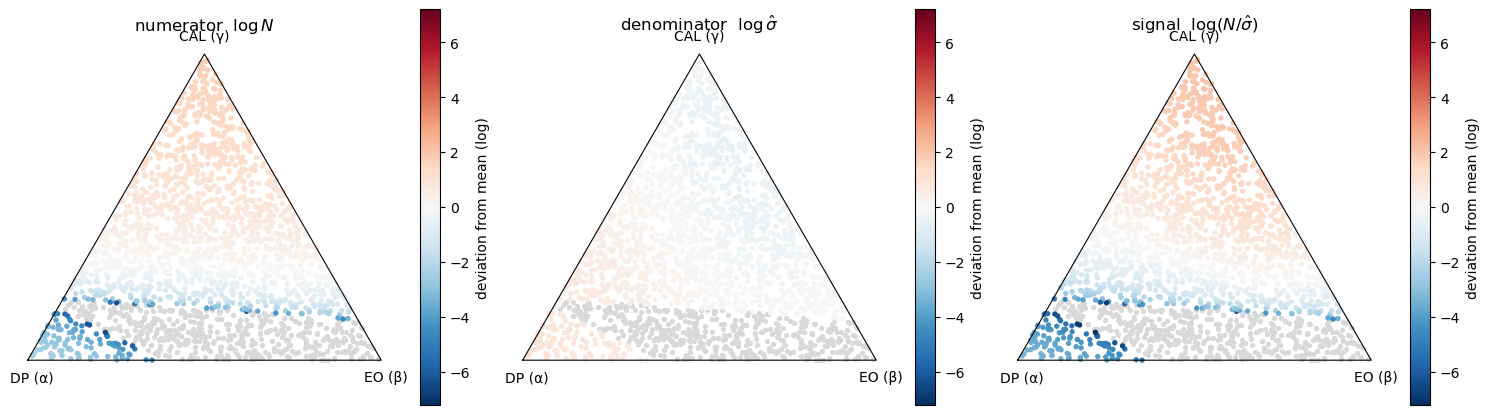

greyed 'nothing to detect' weightings: 23.4%


In [ ]:
def to_xy(a, b, g):
    return b + g/2, g*np.sqrt(3)/2

N   = np.empty(len(weights)); sig = np.empty(len(weights))
for i, (a, b, g) in enumerate(weights):
    comp  = unfairness_score(df_fairness, a, b, g)
    drift = comp - comp.iloc[0]
    N[i]  = drift.max()                       # no clamp
    sig[i] = sigma_hat(np.array([a, b, g]), Sigma)

drifts = N > 0                                 # genuine drift vs "nothing to detect"
x, y   = to_xy(weights[:,0], weights[:,1], weights[:,2])

# log fields, centred on their own mean so panels are comparable and additive
logN   = np.log(N[drifts]);   logN   -= logN.mean()
logsig = np.log(sig[drifts]); logsig -= logsig.mean()
logz   = logN - logsig                         # centred signal = centred N - centred sigma

xd, yd = x[drifts], y[drifts]
xn, yn = x[~drifts], y[~drifts]                # the no-drift bucket

panels = [("numerator  $\\log N$",              logN),
          ("denominator  $\\log\\hat{\\sigma}$", logsig),
          ("signal  $\\log(N/\\hat{\\sigma})$",  logz)]

vmax = max(np.abs(logN).max(), np.abs(logsig).max(), np.abs(logz).max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (title, f) in zip(axes, panels):
    ax.scatter(xn, yn, c="0.85", s=8, zorder=1)          # no-drift bucket, greyed
    pts = ax.scatter(xd, yd, c=f, cmap="RdBu_r",
                     vmin=-vmax, vmax=vmax, s=8, zorder=2)
    ax.plot([0,1,0.5,0], [0,0,np.sqrt(3)/2,0], "k", lw=0.8)
    ax.set_aspect("equal"); ax.axis("off"); ax.set_title(title)
    ax.text(-0.05,-0.06,"DP (α)"); ax.text(0.95,-0.06,"EO (β)")
    ax.text(0.5, np.sqrt(3)/2+0.04, "CAL (γ)", ha="center")
    fig.colorbar(pts, ax=ax, fraction=0.046, label="deviation from mean (log)")
plt.tight_layout(); plt.show()

print(f"greyed 'nothing to detect' weightings: {(~drifts).mean():.1%}")

In [31]:
s_num, s_den, s_z = dp_slope(logN), dp_slope(logsig), dp_slope(logz)
print(f"numerator tilt  {s_num:+.3f}")
print(f"denominator tilt {s_den:+.3f}")
print(f"denominator share {abs(s_den)/(abs(s_num)+abs(s_den)):.0%}")

numerator tilt  -4.015
denominator tilt +1.569
denominator share 28%


cusum  first flag 2009 | n= 9 | [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]
ewma   first flag 2009 | n= 7 | [2009, 2010, 2011, 2012, 2013, 2015, 2017]
and    first flag 2009 | n= 7 | [2009, 2010, 2011, 2012, 2013, 2015, 2017]
or     first flag 2009 | n= 9 | [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]
         min  max  mean  frac_never
variant                            
and      0.0  4.0  1.16        0.31
cusum    0.0  4.0  1.16        0.31
ewma     0.0  3.0  1.50        0.00
or       0.0  3.0  1.50        0.00


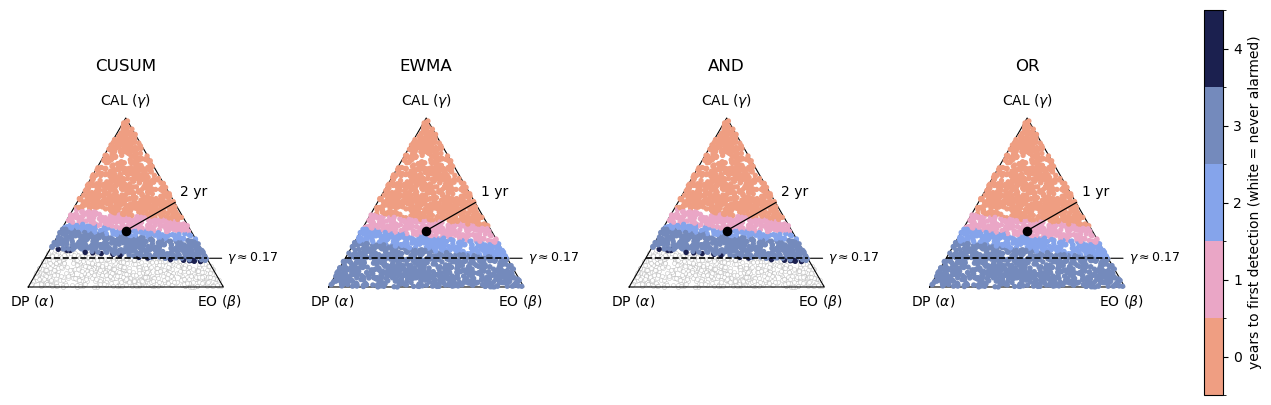

In [62]:
# Plot the delay in alarm - white means no alarm

delay_colours = ["#EF9E82",  # 0  soft salmon   (anchor shared with miss-rate figure)
                 "#EAA6C6",  # 1  soft pink
                 "#85A4EB",  # 2  lilac
                 "#748ABC",  # 3  soft blue
                 "#1B204F"]  # 4  vivid deep blue — deliberately discontinuous
delay_cmap = ListedColormap(delay_colours)
delay_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], delay_cmap.N)


# 1. Pin the anchor: extract each referee's flagged years
def flagged_years(ref, index=df_fairness.index):
    """Sorted years the referee flags. Adapt if the assert below fails."""
    if isinstance(ref, pd.Series):
        s = ref.astype(bool); return list(s.index[s])
    arr = np.asarray(ref)
    if arr.dtype == bool and len(arr) == len(index):
        return list(np.asarray(index)[arr])
    return sorted(int(y) for y in arr) # already an iterable of years

referees = {"cusum": referee_cusum_alarm, "ewma": referee_ewma_alarm,
            "and": referee_and, "or": referee_or}
expected_counts = {"cusum": 9, "ewma": 7, "and": 7, "or": 9}

referee_first = {}
for v, ref in referees.items():
    yrs = flagged_years(ref)
    referee_first[v] = min(yrs)
    print(f"{v:6s} first flag {min(yrs)} | n={len(yrs):2d} | {yrs}")
    assert len(yrs) == expected_counts[v], (
        f"{v}: extracted {len(yrs)} flags, expected {expected_counts[v]} — "
        f"flagged_years() is misreading the referee object; adjust it to the real type")

# 2. Convert first-alarm year to delay, anchored per variant
df_mc["referee_first_year"] = df_mc["variant"].map(referee_first)
df_mc["delay"] = df_mc["first_alarm_year"] - df_mc["referee_first_year"]

print(df_mc.groupby("variant")["delay"]
      .agg(min="min", max="max", mean="mean",
           frac_never=lambda s: s.isna().mean()).round(2))

# 3. Delay simplex
def to_xy(a, b, g):
    return b + g / 2, g * np.sqrt(3) / 2

# Discrete map assumes integer delays 0–4, non-negative. Extend both if either fires.
_d = df_mc["delay"].to_numpy(dtype=float)
assert np.nanmin(_d) >= 0, f"negative delay present ({np.nanmin(_d)}); extend colours/boundaries"
assert int(np.nanmax(_d)) == 4, f"max delay is {int(np.nanmax(_d))}, not 4; adjust colours/boundaries"

fig, axes = plt.subplots(1, 4, figsize=(18, 5), gridspec_kw={"wspace": 0.4})
sc = None
for ax, variant in zip(axes, ["cusum", "ewma", "and", "or"]):
    sub = df_mc[df_mc["variant"] == variant]
    x, y = to_xy(sub["alpha"].to_numpy(), sub["beta"].to_numpy(), sub["gamma"].to_numpy())
    d = sub["delay"].to_numpy(dtype=float)
    missed = np.isnan(d)

    # never-alarmed weightings: white with a light edge, so "no alarm" is visible, not absent
    ax.scatter(x[missed], y[missed], c="white", edgecolors="0.7",
               linewidths=0.3, s=8, zorder=2)
    # finite-delay weightings, one flat colour per integer year
    sc = ax.scatter(x[~missed], y[~missed], c=d[~missed],
                    cmap=delay_cmap, norm=delay_norm, s=8, zorder=3)

    # simplex outline
    ax.plot([0, 1, 0.5, 0], [0, 0, np.sqrt(3) / 2, 0], color="k", lw=0.8)

    # vertex labels — match the miss-rate simplex
    ax.text(0.5, np.sqrt(3) / 2 + 0.04, r"CAL ($\gamma$)", ha="center", va="bottom", fontsize=10)
    ax.text(0.02, -0.03, r"DP ($\alpha$)", ha="center", va="top", fontsize=10)
    ax.text(0.98, -0.03, r"EO ($\beta$)", ha="center", va="top", fontsize=10)

    # cliff line on CUSUM and AND only, matching the miss-rate figure
    g = 0.17; yc = g * np.sqrt(3) / 2
    ax.plot([g / 2, 1 - g / 2], [yc, yc], color="k", lw=1.2, ls="--", zorder=6)
    ax.annotate(r"$\gamma \approx 0.17$", xy=(1 - g / 2, yc), xytext=(1.02, yc),
                ha="left", va="center", fontsize=9,
                arrowprops=dict(arrowstyle="-", color="k", lw=0.8), annotation_clip=False)

    # equal-weight marker — positional parallel with the miss-rate figure
    eq = 1 / 3
    eq_x, eq_y = to_xy(eq, eq, eq)
    eq_row = sub.loc[((sub["alpha"] - eq) ** 2 + (sub["beta"] - eq) ** 2
                      + (sub["gamma"] - eq) ** 2).idxmin()]
    eq_d = eq_row["delay"]
    eq_lbl = "never" if pd.isna(eq_d) else f"{eq_d:.0f} yr"
    ax.scatter(eq_x, eq_y, color="black", s=35, zorder=7)
    ax.annotate(eq_lbl, xy=(eq_x, eq_y), xytext=(eq_x + 0.28, eq_y + 0.20),
                ha="left", va="center", fontsize=10,
                arrowprops=dict(arrowstyle="-", color="black", lw=0.9), annotation_clip=False)

    ax.set_title(variant.upper(), pad=28)
    ax.set_aspect("equal"); ax.axis("off")

cbar = fig.colorbar(sc, ax=axes, ticks=[0, 1, 2, 3, 4],
                    label="years to first detection (white = never alarmed)")
plt.show()

In [ ]:
df_mc.to_csv("../data/processed/mc_results.csv")

## Monte Carlo over the (α, β, γ) simplex — findings, 23 July

### Setup
- 2000 weightings drawn from Dirichlet(1,1,1), seed 0. Uniform over the simplex,
  i.e. the formal statement of "the regulation gives no reason to prefer any weighting".
- Σ from the 200 bootstrap resamples on 2007; σ̂(w) = sqrt(wᵀΣw), verified to 14 s.f.
  against the earlier direct calculation.
- Four detector variants (CUSUM, EWMA-residual, AND, OR), k = 0.5, h = 4.77.
- Each variant scored against its own referee, so differences reflect the weighting
  rather than differences between referees.
- Validation: uniform weights reproduce the previously confirmed CUSUM miss rate of 0.222.

### Result 1 — the outcome is close to all-or-nothing, not a gradient
CUSUM: mean miss rate 0.424, sd 0.428. For a quantity bounded in [0, 1] that is
roughly 87% of the maximum possible sd at that mean.
Breakdown: 34% of weightings miss nothing, 31% miss everything, 35% in between.
The mean describes almost none of the actual outcomes and should not be reported alone.

### Result 2 — the transition is a cliff, not a slope
Performance changes abruptly at roughly γ ≈ 0.17 rather than degrading gradually.
Two deployers choosing γ = 0.15 and γ = 0.20 have made near-identical decisions and
obtained opposite monitors.

### Result 3 — the failing region is where regulatory instinct points
The red region is the DP corner. Demographic parity is the metric closest to
disparate-impact doctrine and the four-fifths rule, so it is the weighting a
good-faith 2007 compliance function would most plausibly favour. The alarm works
only if weight is placed on calibration, which no legal instinct recommends.
[Check: is this overstated? Needs support from the fair-lending literature.]

### Result 4 — the DP/EO collapse, predicted algebraically, confirmed empirically
Colour varies vertically (with γ) and is near-constant horizontally along bands.
Since DP and EO move near-identically across years, α and β enter the composite
drift only through their sum, so the detector depends on γ alone.
Caveat: this holds in the numerator only. In the bootstrap covariance, DP is ~5x
noisier than EO, so the α/β split does affect σ̂ and hence the threshold.

### Result 5 — EWMA cannot be driven to total failure, but is slow
EWMA and OR never exceed miss rates of 0.857 and 0.889; CUSUM and AND both reach 1.0.
However, weightings that never alarm under CUSUM alarm in 2012 under EWMA — five
years after the referee's first flag. Late detection is currently scored as success
by the miss rate; a delay measure is needed.
[Do not generalise: the floor under EWMA likely depends on the 2007 anchor sitting
at the DP/EO peak, which is a feature of the crisis rather than of adaptive detectors.]

### Framing note
The contribution is structural and does not depend on the specific values of
DP/EO/CAL. The magnitudes here are specific to this model and dataset; the mechanism
is not. The optimal weighting is a function of future drift, which is unavailable at
the time the choice must be made.

### Open items
1. Check whether CAL's individual detector drives most of the referee's 9 flagged
   years. If so, "weight CAL heavily" may score well partly by imitating the referee.
2. Add detection delay (first alarm year − referee's first flagged year) alongside miss rate.
3. Store per-year alarms to plot alarm coverage over time.
4. Robustness: refit with a stronger model, regenerate the three series, re-run the
   sweep. Tests whether the DP/EO collapse and the cliff survive higher accuracy.
5. Threshold robustness at h = 4σ and 5σ.